In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import re
import requests
from bs4 import BeautifulSoup


In [2]:
url = "https://aws.amazon.com/what-is/nlp/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

# Extract text content
text = soup.get_text()
print(text[:2000])  # preview















What is Natural Language Processing? - NLP Explained - AWS



























































































Skip to main content




















     
























































Filter: All

 








































English





Contact us
AWS Marketplace

Support  






My account  






















     











Search












































Filter: All

 



















Sign in to console

Create account










































What is Cloud Computing?




Cloud Computing Concepts Hub




Artificial Intelligence




Machine Learning









What is Natural Language Processing (NLP)?



Create an AWS Account


































Page topics




What Is Natural Language Processing (NLP)?
Why is NLP important?
What are NLP use cases for business?
What are the approaches to natural language processing?
What are NLP tas

In [3]:
# Clean text
text = text.lower()
text = re.sub(r'[^a-z\s]', '', text)

# Tokenize
words = text.split()

# Build vocabulary
vocab = list(set(words))
word_to_index = {word:i for i, word in enumerate(vocab)}
index_to_word = {i:word for word, i in word_to_index.items()}

print("Vocabulary size:", len(vocab))


Vocabulary size: 753


In [4]:
# generate skip gram pairs
def generate_skipgrams(words, window_size=2):
    pairs = []
    for i, word in enumerate(words):
        for j in range(-window_size, window_size+1):
            if j != 0 and i+j >= 0 and i+j < len(words):
                pairs.append((word_to_index[word], word_to_index[words[i+j]]))
    return pairs

window_size = 3
pairs = generate_skipgrams(words, window_size)

print("Sample pairs:", pairs[:10])


Sample pairs: [(0, 422), (0, 249), (0, 7), (422, 0), (422, 249), (422, 7), (422, 405), (249, 0), (249, 422), (249, 7)]


In [5]:
# create training data 
def generate_training_data(pairs, vocab_size, num_neg=2):
    X = []
    y = []
    
    for target, context in pairs:
        X.append([target, context])
        y.append(1)
        
        # negative samples
        for _ in range(num_neg):
            neg_word = np.random.randint(0, vocab_size)
            X.append([target, neg_word])
            y.append(0)
    
    return np.array(X), np.array(y)

X, y = generate_training_data(pairs, len(vocab))
print("Training data shape:", X.shape, y.shape)

Training data shape: (40878, 2) (40878,)


In [6]:
# build skip gram model
embedding_dim = 100

target_input = tf.keras.Input(shape=())
context_input = tf.keras.Input(shape=())

embedding = tf.keras.layers.Embedding(len(vocab), embedding_dim)

target_embed = embedding(target_input)
context_embed = embedding(context_input)

dot_product = tf.keras.layers.Dot(axes=1)([target_embed, context_embed])
dot_product = tf.keras.layers.Reshape((1,))(dot_product)

output = tf.keras.layers.Dense(1, activation='sigmoid')(dot_product)

model = tf.keras.Model(inputs=[target_input, context_input], outputs=output)
model.compile(loss='binary_crossentropy', optimizer='adam')

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100)       │     75,300 │ input_layer[0][0… │
│ (Embedding)         │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1)         │          0 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          2 │ reshape[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 75,302 (294.15 KB)

 Trainable params: 75,302 (294.15 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# history_10 = model.fit([X[:,0], X[:,1]], y, epochs=10, batch_size=256)

In [8]:
history_25 = model.fit([X[:,0], X[:,1]], y, epochs=25, batch_size=256)


Epoch 1/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6770
Epoch 2/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6109
Epoch 3/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5320
Epoch 4/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4566
Epoch 5/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3899
Epoch 6/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3361
Epoch 7/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2939
Epoch 8/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2610
Epoch 9/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2353
Epoch 10/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2149
Epoch 11/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1988
Epoch 12/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1857
Epoch 13/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1755
Epoch 14/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1669
Epoch 15/25
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - lo

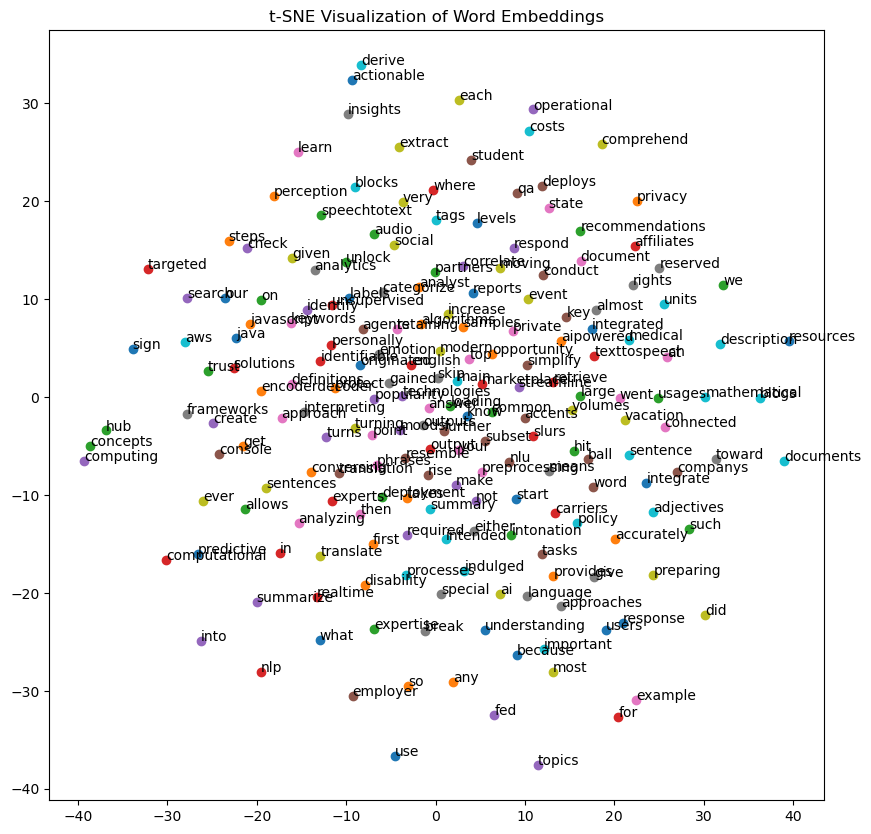

In [9]:
# Visualizing Embeddings with t-SNE
weights = model.layers[2].get_weights()[0]

tsne = TSNE(n_components=2)
reduced = tsne.fit_transform(weights[:200])  # limit for clarity

plt.figure(figsize=(10,10))
for i in range(200):
    plt.scatter(reduced[i,0], reduced[i,1])
    plt.annotate(index_to_word[i], (reduced[i,0], reduced[i,1]))

plt.title("t-SNE Visualization of Word Embeddings")
plt.show()


Task Solutions
# 1
increasing the embedding from 50 to 100 leads to richer semantic representation, however, higher dimensions lead to harder visualization
# 2
larger window size captures broader context
# 3
better convergence as epochs is increased from 10 to 25
# 4
without negative sampling, there is high loss. Negative sampling improves discriminations enabling the model to better distinguish real vs fake word pairs
# 5
tf.keras.model is used to build Neural Networks. Skip-gram predicts context words from a target word optimized using biinary cross entropy